In [1]:
!pip install insightface onnxruntime opencv-python scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 7.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 87.6 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp312-cp312-linux_x86_64.whl size=1071490 sha256=38411e0d798a56cc616c852cff70b4f765cfb13b337cca8745a0c41ce9286146
  Stored in directory: /root/.cache/pip/wheels/73/3c/e2/6d4815e8a8b33a2006554d65ce0d1f973e768f4c7a222fa675
Successfully built insightface


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
ENROLLED_PATH = "/content/drive/MyDrive/M tech Acadamic Project/SmartSecurity/enrolled_faces"
TEST_PATH = "/content/drive/MyDrive/M tech Acadamic Project/SmartSecurity/test_images"

In [4]:
!pip install insightface onnxruntime

In [5]:
import cv2
import os
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from insightface.app import FaceAnalysis

In [6]:
app = FaceAnalysis(name='buffalo_l')
app.prepare(ctx_id=0)   # 0 = GPU, -1 = CPU

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:11<00:00, 23660.83KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


In [7]:
import os

# List contents of Google Drive MyDrive to help verify folder paths
print(os.listdir('/content/drive/MyDrive'))

['My Tracks', 'Bfg Dec salary', 'BFG APPOINTMENT LETTER', 'DOCUMENTS', 'Baji plastic notes', 'Resume', 'IAC', 'Ford CC', 'Personal', 'To-do list.gsheet', 'Signed.zip', 'German Practice.gslides', 'Naturals membership', 'M tech Acadamic Project', 'Untitled spreadsheet.gsheet', 'German Practice.gsheet', 'Mechanical Upskill.gsheet', 'GERMANY CAR COMPANIES LIST.gsheet', 'Lightyear', 'invoice.PDF', 'Suresh karre Marriage invitation list.gsheet', 'Suresh Bava__marriage', 'Colab Notebooks', 'notifyN_backup (2).nak', 'notifyN_backup (1).nak', 'notifyN_backup.nak', 'delete', 'Developing an AI Chatbot for Andhra University Admissions.gslides', 'sunitha engagement', 'Inferential Statistics_final.gdoc', 'Copy of Decicion Tree, Random Forest-5 July.pptx', 'SRM', 'nba_final (2).csv', 'Copy of OnlineRetail (1).csv', 'Copy of OnlineRetail.csv', 'Copy of programming_jokes.json', 'LLM PRACTICE DELETE', 'Credit cards', "Review 1 China's Automotive Dominance Strategic Analysis Project Category: RESEARCH.gs

In [8]:
import os

enrolled_db = {}

# Ensure the directory exists
if not os.path.exists(ENROLLED_PATH):
    os.makedirs(ENROLLED_PATH, exist_ok=True)
    print(f"Created directory: {ENROLLED_PATH}")

for file in os.listdir(ENROLLED_PATH):
    img_path = os.path.join(ENROLLED_PATH, file)

    img = cv2.imread(img_path)
    faces = app.get(img)

    if len(faces) > 0:
        embedding = faces[0].embedding
        person_name = file.split('.')[0]   # person1, person2...

        enrolled_db[person_name] = embedding
        print(f"✅ Enrolled: {person_name}")
    else:
        print(f"❌ No face found in {file}")

✅ Enrolled: person1
✅ Enrolled: person2
✅ Enrolled: person3
✅ Enrolled: person4
✅ Enrolled: person5


In [9]:
def recognize_face(test_embedding, enrolled_db):
    best_match = None
    best_score = -1

    for name, emb in enrolled_db.items():
        score = cosine_similarity([test_embedding], [emb])[0][0]

        if score > best_score:
            best_score = score
            best_match = name

    return best_match, best_score

In [10]:
import os

results = []

# Ensure the test directory exists
if not os.path.exists(TEST_PATH):
    os.makedirs(TEST_PATH, exist_ok=True)
    print(f"Created directory: {TEST_PATH}")

for file in os.listdir(TEST_PATH):
    img_path = os.path.join(TEST_PATH, file)

    img = cv2.imread(img_path)
    faces = app.get(img)

    if len(faces) > 0:
        test_embedding = faces[0].embedding

        identity, score = recognize_face(test_embedding, enrolled_db)

        # Threshold logic
        if score > 0.4:
            status = "KNOWN"
        else:
            status = "UNKNOWN"

        print(f"\n🖼 Image: {file}")
        print(f"👤 Identity: {identity}")
        print(f"📊 Score: {score:.4f}")
        print(f"🔎 Status: {status}")

        results.append((file, identity, score, status))

    else:
        print(f"\n❌ No face detected in {file}")


🖼 Image: using_phone.jpg
👤 Identity: person1
📊 Score: 0.6028
🔎 Status: KNOWN

🖼 Image: group_discussion.jpg
👤 Identity: person1
📊 Score: 0.0735
🔎 Status: UNKNOWN

🖼 Image: eating_food.jpg
👤 Identity: person2
📊 Score: 0.5171
🔎 Status: KNOWN

🖼 Image: sleeping.jpg
👤 Identity: person4
📊 Score: 0.4553
🔎 Status: KNOWN

🖼 Image: working_on_laptop.jpg
👤 Identity: person5
📊 Score: 0.6424
🔎 Status: KNOWN


In [11]:
import pandas as pd

df = pd.DataFrame(results, columns=["Image", "Identity", "Score", "Status"])
df

,Image,Identity,Score,Status
0,using_phone.jpg,person1,0.602846,KNOWN
1,group_discussion.jpg,person1,0.073545,UNKNOWN
2,eating_food.jpg,person2,0.517134,KNOWN
3,sleeping.jpg,person4,0.455303,KNOWN
4,working_on_laptop.jpg,person5,0.642387,KNOWN


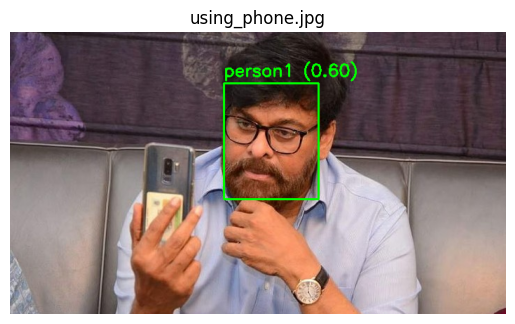

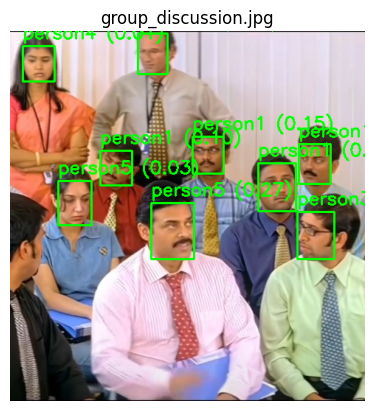

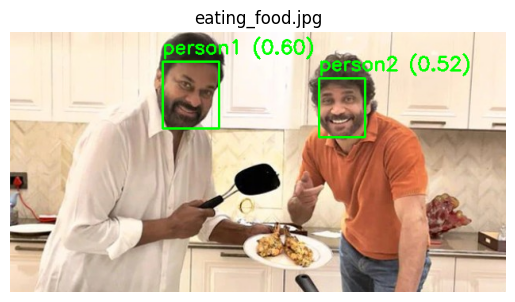

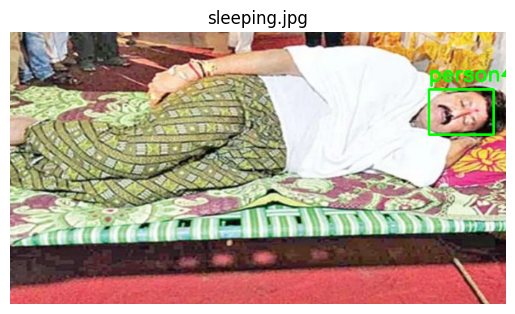

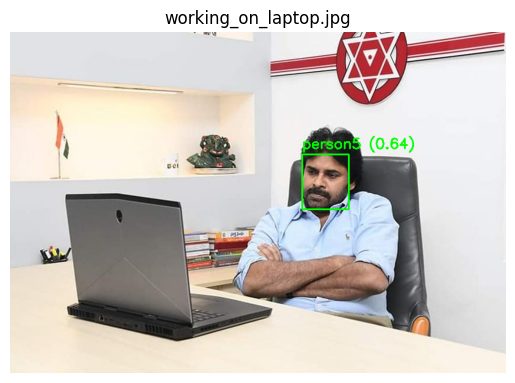

In [12]:
from matplotlib import pyplot as plt

for file in os.listdir(TEST_PATH):
    img_path = os.path.join(TEST_PATH, file)
    img = cv2.imread(img_path)

    faces = app.get(img)

    for face in faces:
        x1, y1, x2, y2 = face.bbox.astype(int)
        emb = face.embedding

        identity, score = recognize_face(emb, enrolled_db)

        label = f"{identity} ({score:.2f})"

        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(img, label, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

    # 🔥 SHOW IMAGE (COLAB FIX)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(file)
    plt.axis('off')
    plt.show()